<a href="https://colab.research.google.com/github/krishnakanthkona-3110/My-DSA-Journey/blob/main/Dynamic_Programming/DSA_Dynamic_Programming_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://notability.com/n/1YZRHyRRO7hev_ISn4q6zb

# 1Q). Fractional Knapsack

1Q). Given two integer arrays A and B of size N each which represent values and weights associated with N items respectively.

Also given an integer C which represents knapsack capacity.

Find out the maximum total value that we can fit in the knapsack. If the maximum total value is ans, then return ⌊ans × 100⌋ , i.e., floor of (ans × 100).

NOTE:

You can break an item for maximizing the total value of the knapsack

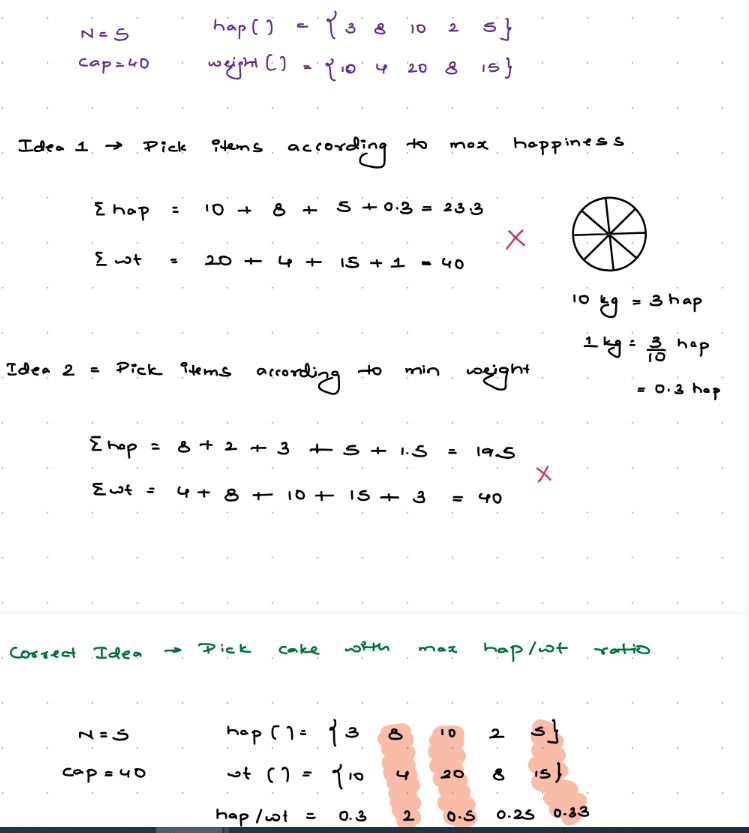

In [ ]:
def frac_snap(v,w,c):

  items = []
  n = len(v)

  # Step 1: create (ratio, value, weight)
  for i in range(n):
    ratio = v[i]/w[i]

    items.append((ratio, v[i],w[i]))

  # Step 2: sort by ratio descending
  items.sort(key = lambda x:x[0],reverse=True)
  # items.sort(reverse=True)

  total_value = 0.0

  # Step 3: pick items
  for ratio, value, weight in items:
    if c >= weight:
      total_value +=  value
      c -= weight
    else:
      total_value += ratio*c
      break

  return total_value

In [ ]:
frac_snap([3,8,10,2,5],[10,4,20,8,15],40)

23.3

1. Creates a list of items with their ratio, value, and weight, which takes O(n) time.
2. Sorts the list of items based on the ratio in descending order, which takes O(n log n) time.
3. Iterates through the sorted list to select items or fractions thereof, which takes O(n) time in the worst case.

Overall time complexity: O(n log n) due to the sorting step, as it dominates the other linear operations.

Space complexity:
- The items list stores n tuples, each containing three elements, so it requires O(n) space.
- Additional variables use constant space.

Overall space complexity: O(n).

# 2Q). 0-1 Knapsack
 Given two integer arrays A and B of size N each which represent values and weights associated with N items respectively.

Also given an integer C which represents knapsack capacity.

Find out the maximum value subset of A such that sum of the weights of this subset is smaller than or equal to C.

NOTE:

You cannot break an item, either pick the complete item, or don’t pick it (0-1 property).

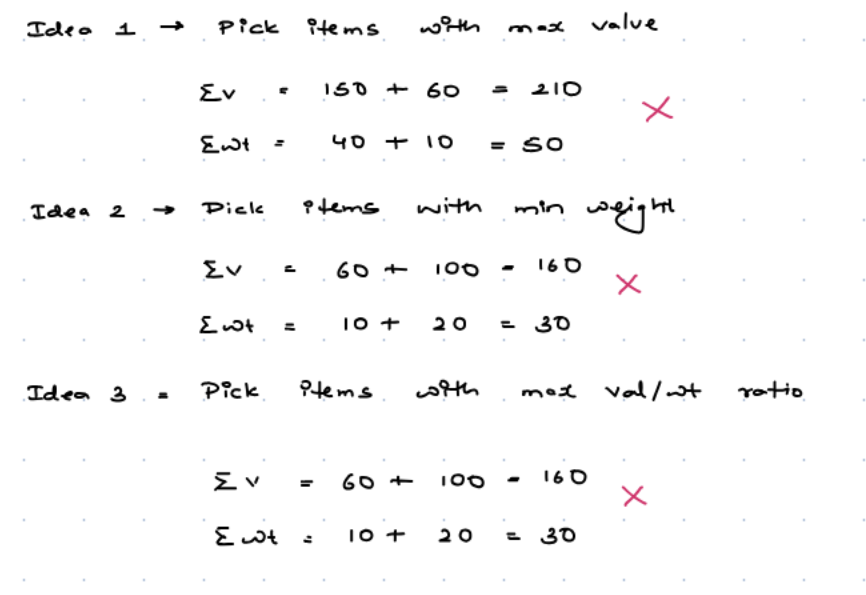

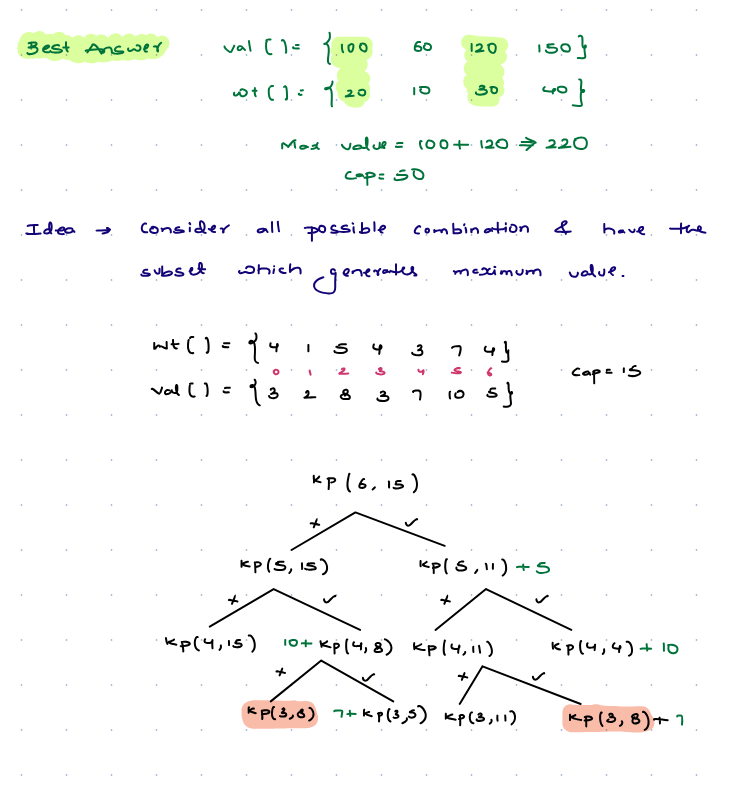

same sub problems, so recursion can be applied

In [3]:
def knapsack(i, j, wt, val, dp):
    # Base case
    if i < 0 or j == 0:
        return 0

    # Memoization check
    if dp[i][j] != -1:
        return dp[i][j]

    # Not pick
    not_pick = knapsack(i - 1, j, wt, val, dp)

    # Pick
    pick = 0
    if wt[i] <= j:
        pick = knapsack(i - 1, j - wt[i], wt, val, dp) + val[i]

    # Store and return
    dp[i][j] = max(pick, not_pick)
    return dp[i][j]


# Input
wt = [3, 6, 5, 2]
val = [12, 20, 15, 6]
cap = 7
n = len(wt)

# DP array
dp = [[-1] * (cap + 1) for _ in range(n)]

# Call function
result = knapsack(n - 1, cap, wt, val, dp)
print(result)   # Output: 21


21


In [5]:
wt = [3, 6, 5, 2]
val = [12, 20, 15, 6]
cap = 7
n = len(wt)

# Create DP table
dp = [[0] * (cap + 1) for _ in range(n + 1)]

# Fill the table
for i in range(1, n + 1):
    for j in range(1, cap + 1):

        # Not pick
        rej = dp[i - 1][j]

        # Pick
        sel = 0
        w = wt[i - 1]
        v = val[i - 1]

        if w <= j:
            sel = dp[i - 1][j - w] + v

        # Take maximum
        dp[i][j] = max(sel, rej)

# Final answer
print(dp[n][cap])   # Output: 21

21


Time Complexity:
- Each state in the DP table is defined by two parameters: the item index (i) and the remaining capacity (j).
- The total number of states is n * (cap + 1), where n is the number of items.
- Each state is computed once and stored in the DP table.
- Therefore, the overall time complexity is O(n * cap).

Space Complexity:
- The DP table requires space proportional to n * (cap + 1), which is O(n * cap).
- Additionally, the recursion stack depth can go up to O(n) in the worst case, but this is generally overshadowed by the DP table space.
- Hence, the total space complexity is O(n * cap).

In summary:
Time complexity: O(n * cap)
Space complexity: O(n * cap)

The time complexity is O(N × capacity) since we fill a DP table of size N × cap, and the space complexity is also O(N × cap), which can be optimized to O(cap) using a 1D DP array

In [9]:
dp = [0] * (cap + 1)

for i in range(n):
    for j in range(cap, wt[i] - 1, -1):   # 🔥 backward
        dp[j] = max(dp[j], val[i] + dp[j - wt[i]])

In [8]:
wt = [3, 6, 5, 2]
val = [12, 20, 15, 6]
cap = 7
n = 4

In [12]:
dp[cap]

21

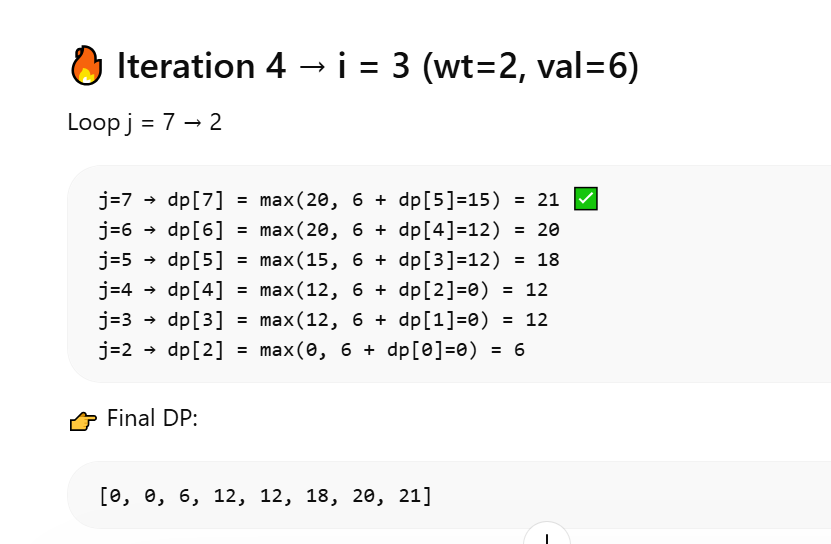